In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

Import my colony counts recorded in Excel

In [2]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\26_2_2026\26_2_2026.xlsx"
data = pd.read_excel(path)

#Set dose levels and used plating numbers
Dose_levels = np.array([0, 2, 5, 8])
Plating_x = np.array([250, 250, 2500, 10000])
Plating_lp = np.array([500, 1000, 5000, 40000])
Plating_hp = np.array([500, 2000, 20000, 60000])

#Edge correction
Adjusted_Plating_numbers_x = Plating_x #0.9368*Plating_numbers
Adjusted_Plating_numbers_lp = Plating_lp #0.9368*Plating_numbers_h
Adjusted_Plating_numbers_hp = Plating_hp #0.9368*Plating_numbers_h

print(data)

#Make folder for writing data
foldername = 'EXP_' + os.path.splitext(os.path.split(path)[-1])[0]
folderpath = os.path.join(r'C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results', foldername)
os.mkdir(folderpath)

    Flask nr       Count  Dose       Rad  Triplicate
0          1   63.000000     5  Proton H           3
1          2   45.000000     5         X           3
2          3  166.000000     5  Proton L           2
3          4   17.000000     2         X           2
4          5   62.000000     5  Proton M           2
5          6   30.000000     2         X           1
6          7   97.000000     8  Proton L           3
7          8   20.000000     0         X           5
8          9    7.803922     8         X           2
9         10   28.000000     0         X           6
10        11   91.000000     2  Proton H           2
11        12   19.000000     8  Proton M           2
12        13   17.000000     2         X           3
13        14   18.000000     8  Proton H           3
14        15   85.000000     2  Proton H           3
15        16   78.000000     0         P           6
16        17   45.000000     5  Proton H           1
17        18   87.000000     0         P      

In [3]:
def Perform_LQ_fit(doses, survival):
    #Generate LQ fit

    #inputs:
    #doses = list of used dose levels
    #survival = dictionary with survival data per dose level

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    def LQ_function(d, a, b):
        return -(a*d + b*(np.square(d)))

    xvals = np.array(doses)
    yvals = np.array(list(survival.values()))
    yvals = np.log(yvals)

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, xvals, yvals, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [4]:
def Parse_data(doselevels, platingnumbers, input):
    #Split colony counting data into cell survival per dose level

    #inputs:
    #doselevels = list of the used dose levels
    #platingnumbers = list of the plating numbers for each dose level
    #input = dataframe with the dose and count for each sample

    output_survival = {}
    output_std = {}

    output_df = pd.DataFrame(columns=['Dose', 'Rad', 'Plated', 'Count_1', 'Count_2', 'Count_3'])
    
    for i in range(len(doselevels)):
        dose = doselevels[i]
        plating_number = platingnumbers[i]

        #Isolate data from this dose level
        dose_level_data = input[input['Dose'] == dose]

        #Write to dataframe
        newrow = {}
        newrow['Dose'] = dose
        for row in dose_level_data.itertuples():
            trip = row.Triplicate
            newrow[f"Count_{trip}"] = row.Count
        newrow['Rad'] = row.Rad 
        newrow['Plated'] = plating_number   
        newrow = pd.DataFrame([newrow])
        output_df = pd.concat([output_df, newrow], ignore_index=True)

        #Find average colony count
        average_count = dose_level_data['Count'].mean()

        #Calculate survival
        if i == 0:
            #If we're on the control sample, store value
            control_survival = average_count/plating_number
        survival = (average_count/plating_number)/control_survival

        #Write survival to dictionary
        output_survival[f"{dose} Gy"] = survival
        output_std[f"{dose} Gy"] = (dose_level_data['Count'].std()/plating_number)/control_survival


    return output_survival, output_std, output_df


Plot data and generate LQ curve for X-rays

C:\Users\bhaan\AppData\Local\Temp\ipykernel_36664\2372576065.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


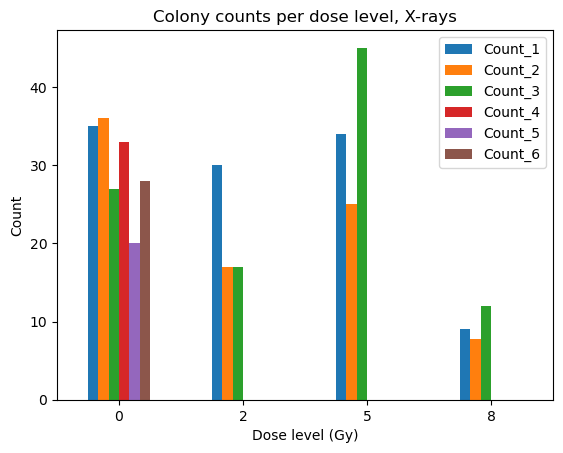

In [5]:
#Filter out X-ray results
X_ray_samples = data[data['Rad'] == 'X']

#Split per dose level
X_ray_survival, X_ray_survival_std, X_ray_df = Parse_data(Dose_levels, Adjusted_Plating_numbers_x, X_ray_samples)

#Save df
X_ray_df.to_excel(os.path.join(folderpath,'X-rays.xlsx'), index=False)

#Make bar plot of colony counts
X_ray_df.plot(x="Dose", y=["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"], kind="bar", rot=0)
plt.title('Colony counts per dose level, X-rays')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')
plt.savefig(os.path.join(folderpath,'Colony counts X-ray.jpeg'))
   

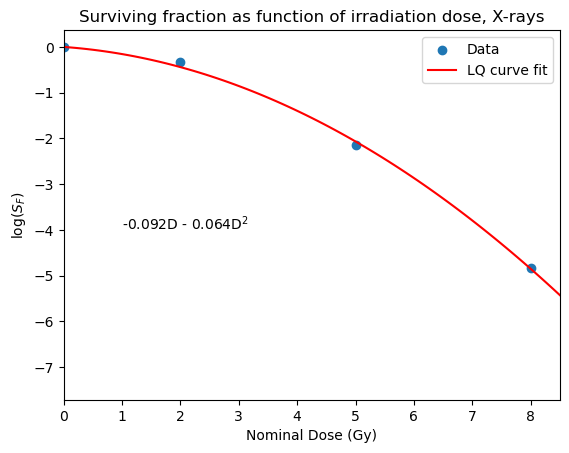

In [6]:
#Generate LQ fit plot
params_x, LQ_func = Perform_LQ_fit(Dose_levels, X_ray_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), label='LQ curve fit', color = 'r')
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, X-rays')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
plt.savefig(os.path.join(folderpath,'Survival curve X-ray.jpeg'))

Plot data and generate LQ curve for protons low LET

C:\Users\bhaan\AppData\Local\Temp\ipykernel_36664\2372576065.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


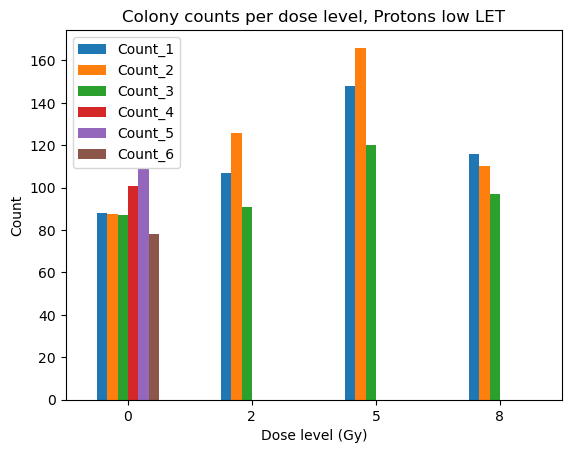

In [7]:
#Filter out proton low LET results
Proton_low_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H') & (data['Rad'] != 'Proton M')]

#Split per dose level
Proton_low_survival, Proton_low_survival_std, Proton_low_df = Parse_data(Dose_levels, Adjusted_Plating_numbers_lp, Proton_low_samples)

#save df
Proton_low_df.to_excel(os.path.join(folderpath,'Proton low.xlsx'), index=False)

#Make bar plot of colony counts
Proton_low_df.plot(x="Dose", y=["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"], kind="bar", rot=0)
plt.title('Colony counts per dose level, Protons low LET')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')
plt.savefig(os.path.join(folderpath,'Colony counts protons low.jpeg'))


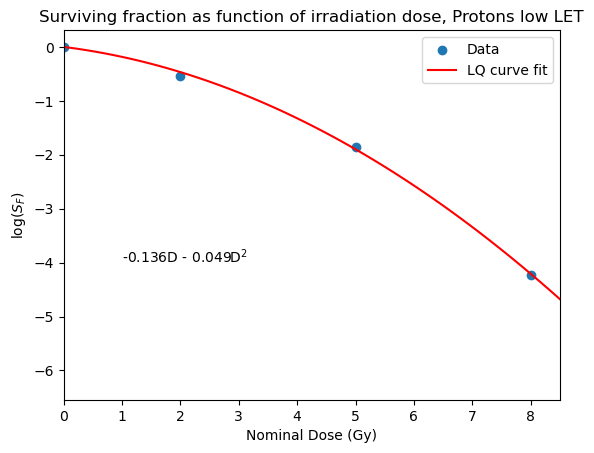

In [8]:
#Generate LQ fit plot
params_lp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_low_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), label='LQ curve fit', color='r')
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons low LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_lp[0],3)}D - {round(params_lp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
plt.savefig(os.path.join(folderpath,'Survival curve protons low.jpeg'))

C:\Users\bhaan\AppData\Local\Temp\ipykernel_36664\2372576065.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


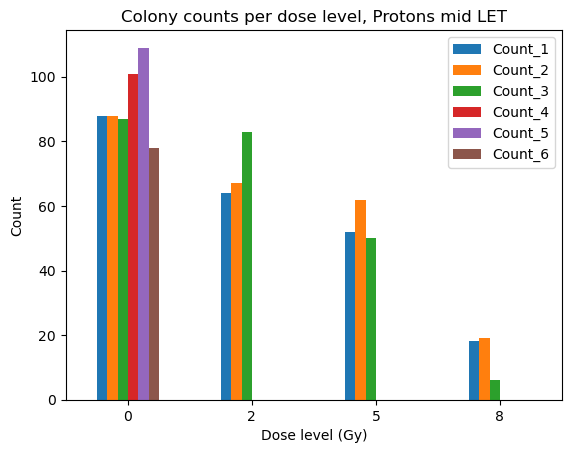

In [9]:
#Filter out proton mid LET results
Proton_mid_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H') & (data['Rad'] != 'Proton L')]

#Split per dose level
Proton_mid_survival, Proton_mid_survival_std, Proton_mid_df = Parse_data(Dose_levels, Adjusted_Plating_numbers_lp, Proton_mid_samples)

#save df
Proton_mid_df.to_excel(os.path.join(folderpath,'Proton mid.xlsx'), index=False)

#Make bar plot of colony counts
Proton_mid_df.plot(x="Dose", y=["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"], kind="bar", rot=0)
plt.title('Colony counts per dose level, Protons mid LET')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')
plt.savefig(os.path.join(folderpath,'Colony counts protons mid.jpeg'))

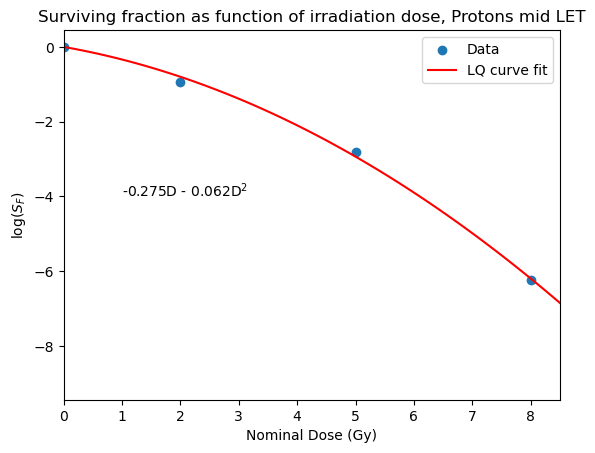

In [10]:
#Generate LQ fit plot
params_mp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_mid_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_mid_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_mp[0], params_mp[1]), label='LQ curve fit', color='r')
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons mid LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_mp[0],3)}D - {round(params_mp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
plt.savefig(os.path.join(folderpath,'Survival curve protons mid.jpeg'))

Plot data and generate LQ curve for protons high LET

C:\Users\bhaan\AppData\Local\Temp\ipykernel_36664\2372576065.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


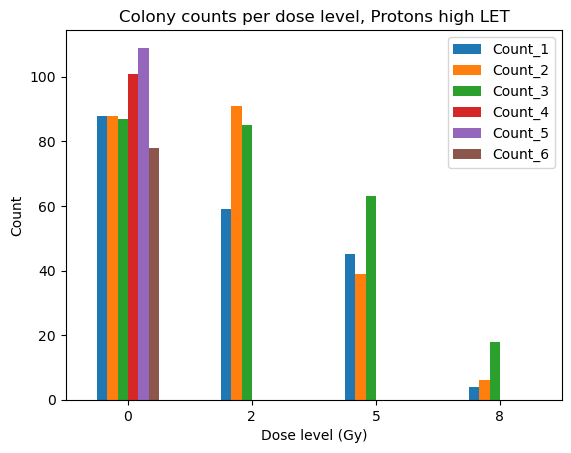

In [11]:
#Filter out proton high LET results
Proton_high_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton L') & (data['Rad'] != 'Proton M')]

#Split per dose level
Proton_high_survival, Proton_high_survival_std, Proton_high_df = Parse_data(Dose_levels, Adjusted_Plating_numbers_hp, Proton_high_samples)

#save df
Proton_high_df.to_excel(os.path.join(folderpath,'Proton high.xlsx'), index=False)

#Make bar plot of colony counts
Proton_high_df.plot(x="Dose", y=["Count_1", "Count_2", "Count_3","Count_4", "Count_5", "Count_6"], kind="bar", rot=0)
plt.title('Colony counts per dose level, Protons high LET')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')
plt.savefig(os.path.join(folderpath,'Colony counts protons high.jpeg'))

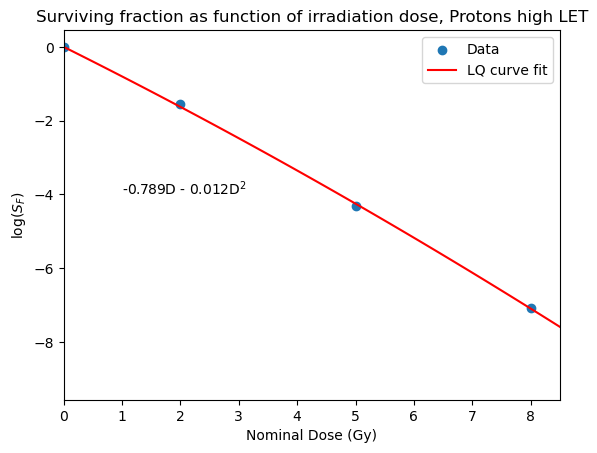

In [12]:
#Generate LQ fit plot
params_hp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_high_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), label='LQ curve fit', color='r')
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons high LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_hp[0],3)}D - {round(params_hp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
plt.savefig(os.path.join(folderpath,'Survival curve protons high.jpeg'))

Plot all data together

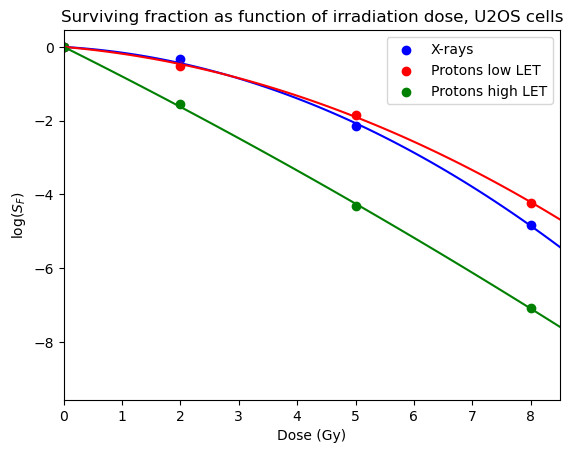

In [13]:
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), color='b', label='X-rays')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color = 'b')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Protons low LET', color='r')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), color='r')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Protons high LET', color='g')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), color='g')

plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.legend()
plt.savefig(os.path.join(folderpath,'Survival curves together.jpeg'))

Calculate RBE from LQ curve fits for a given survival level.

In [14]:
#Set survival level
Survival_level = 0.37

xdata = np.linspace(0,8,1000)

#Survival data from LQ fit for each
ydata_x = LQ_func(xdata, params_x[0], params_x[1])
ydata_lp = LQ_func(xdata, params_lp[0], params_lp[1])
ydata_hp = LQ_func(xdata, params_hp[0], params_hp[1])

#Define interpol objects
interp_x = interp1d(ydata_x, xdata)
interp_lp = interp1d(ydata_lp, xdata)
interp_hp = interp1d(ydata_hp, xdata)

#Interpolate the survival level from lq fits
D_x = interp_x(np.log(Survival_level))
print('D_x: ' + str(round(float(D_x),2)) + ' Gy')
D_lp = interp_lp(np.log(Survival_level))
print('D_lp: ' + str(round(float(D_lp),2)) + ' Gy')
D_hp = interp_hp(np.log(Survival_level))
print('D_hp: ' + str(round(float(D_hp),2)) + ' Gy')

#RBE
RBE_lp = D_x/D_lp
print('RBE low LET: ' + str(round(RBE_lp,2)))

RBE_hp = D_x/D_hp
print('RBE high LET: ' + str(round(RBE_hp,2)))

D_x: 3.28 Gy
D_lp: 3.33 Gy
D_hp: 1.24 Gy
RBE low LET: 0.98
RBE high LET: 2.65
